# Setup

### Imports

In [1]:
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

### Constans

In [2]:
SEED = 42
FEATURES = ["temp_dry", "humidity", "wind_dir", "wind_speed", "precip_past1h",]# "pressure"]

### Sampling

In [3]:
def get_closest_row(data, timestamp):
    abs_difference = abs(data['observed'] - timestamp)
    closest_row = data.iloc[abs_difference.idxmin()]
    return closest_row

def get_data_samples(data, features, seed=42, days_range=7, n=10000, extra_points=[]):
    np.random.seed(seed)
    data_samples = data.sample(n=min(len(data), n), replace=False, random_state=seed)
    data_samples["future_observed"] = data_samples["observed"] + (np.random.rand(data_samples.shape[0]) * 60 * 60 * 24 * days_range)

    new_cols = {}
    for row in data_samples.iloc:
        future_row = get_closest_row(data, row["future_observed"])
        for feature in features:
            new_cols.setdefault(f"future_{feature}", [])
            new_cols[f"future_{feature}"].append(future_row[feature])

        for extra_point in extra_points:
            extra_row = get_closest_row(data, row["observed"] - 60 * 60 * extra_point)
            for feature in features:
                new_cols.setdefault(f"past{extra_point}h_{feature}", [])
                new_cols[f"past{extra_point}h_{feature}"].append(extra_row[feature])

    data_samples["relative_hours"] = ((data_samples["future_observed"] - data_samples["observed"]) // 3600)
    data_samples = data_samples.drop(["observed", "future_observed"], axis="columns")

    for key, value in new_cols.items():
        data_samples[key] = value

    return data_samples

### Set splitting

In [4]:
def split_set(X, y, seed):
    X_tune, X_test, y_tune, y_test = train_test_split(X, y, test_size=.2, random_state=seed)
    X_train, X_validate, y_train, y_validate = train_test_split(X_tune, y_tune, test_size=.2, random_state=seed)
    return ((X_train, y_train), (X_validate, y_validate), (X_test, y_test))

### Metrics

In [5]:
from sklearn.metrics import r2_score, root_mean_squared_error

def compute_metrics(estimator, sets):
    n_features = sets[0][2].shape[1]
    metrics = [("r2", r2_score), ("RMSE", root_mean_squared_error)]
    metric_outputs = {"feature": [*(sets[0][2].iloc[:, i].name for i in range(n_features)), "all"]}
    predictions = [estimator.predict(set[1]) for set in sets]

    for metric_label, metric in metrics:
        for set_idx, (set_label, _, y) in enumerate(sets):
            for feature_idx in range(n_features):
                metric_outputs.setdefault(f"{metric_label}_{set_label}", [])
                metric_outputs[f"{metric_label}_{set_label}"].append(metric(y.iloc[:, feature_idx], [row[feature_idx] for row in predictions[set_idx]]))
            metric_outputs[f"{metric_label}_{set_label}"].append(metric(y, predictions[set_idx]))
    print(pd.DataFrame(metric_outputs))

def fit_and_score(model, sets):
    model.fit(*(sets[0]))
    compute_metrics(model, [("train", *(sets[0])), ("validate", *(sets[1]))])


### Plotting

In [6]:
def plot_temps(model, date, temp, humidity, pressure, wind_dir, wind_speed, precip, labels):
    hours = range(24 * 7 + 1)
    inputs = pd.DataFrame()
    for hour in hours:
        inputs = pd.concat([
            inputs,
            pd.DataFrame(
                {
                    "temp_dry": [temp],
                    "humidity": [humidity],
                    # "pressure": [pressure],
                    "wind_dir": [wind_dir],
                    "wind_speed": [wind_speed],
                    "precip_past1h": [precip],
                    "year": date.year,
                    "month": date.month,
                    "day": date.month,
                    "hour": date.hour,
                    "relative_hours": [hour],
                }
            ),
        ])
    predictions = model.predict(inputs)
    plt.figure()
    plt.plot(hours, predictions)
    plt.legend(labels)
    plt.show()

### Pipeline functions

In [7]:
def drop_columns(X, columns):
    return X.drop(columns, axis="columns")

def drop_nan(X):
    return X.dropna()

def drop_before(X, before_date):
    return X.drop(X[X["observed"] < before_date.timestamp()].index)

def drop_after(X, after_date):
    return X.drop(X[X["observed"] >= after_date.timestamp()].index)

def _encode_cyclic(value, range_start, range_stop):
    value = (value - range_start) / (range_stop - range_start)
    x = (np.sin(2 * np.pi * value) + 1) / 2
    y = (np.cos(2 * np.pi * value) + 1) / 2
    return x, y

def split_time(X, year=True, month=True, day=True, hour=True, minute=False, second=False, make_cyclic=False):
    X = X.copy()
    if year:
        X["year"] = X[["observed"]].apply(lambda row: datetime.fromtimestamp(row["observed"]).year, axis="columns")
    if month:
        if not make_cyclic:
            X["month"] = X[["observed"]].apply(lambda row: datetime.fromtimestamp(row["observed"]).month, axis="columns")
        else:
            X["month_sin"] = X[["observed"]].apply(lambda row: _encode_cyclic(datetime.fromtimestamp(row["observed"]).month, 1, 12)[0], axis="columns")
            X["month_cos"] = X[["observed"]].apply(lambda row: _encode_cyclic(datetime.fromtimestamp(row["observed"]).month, 1, 12)[1], axis="columns")
    if day:
        if not make_cyclic:
            X["day"] = X[["observed"]].apply(lambda row: datetime.fromtimestamp(row["observed"]).day, axis="columns")
        else:
            X["day_sin"] = X[["observed"]].apply(lambda row: _encode_cyclic(datetime.fromtimestamp(row["observed"]).day, 1, 31)[0], axis="columns")
            X["day_cos"] = X[["observed"]].apply(lambda row: _encode_cyclic(datetime.fromtimestamp(row["observed"]).day, 1, 31)[1], axis="columns")
    if hour:
        if not make_cyclic:
            X["hour"] = X[["observed"]].apply(lambda row: datetime.fromtimestamp(row["observed"]).hour, axis="columns")
        else:
            X["hour_sin"] = X[["observed"]].apply(lambda row: _encode_cyclic(datetime.fromtimestamp(row["observed"]).hour, 0, 23)[0], axis="columns")
            X["hour_cos"] = X[["observed"]].apply(lambda row: _encode_cyclic(datetime.fromtimestamp(row["observed"]).hour, 0, 23)[1], axis="columns")
    if minute:
        if not make_cyclic:
            X["minute"] = X[["observed"]].apply(lambda row: datetime.fromtimestamp(row["observed"]).minute, axis="columns")
        else:
            X["minute_sin"] = X[["observed"]].apply(lambda row: _encode_cyclic(datetime.fromtimestamp(row["observed"]).minute, 0, 59)[0], axis="columns")
            X["minute_cos"] = X[["observed"]].apply(lambda row: _encode_cyclic(datetime.fromtimestamp(row["observed"]).minute, 0, 59)[1], axis="columns")
    if second:
        if not make_cyclic:
            X["second"] = X[["observed"]].apply(lambda row: datetime.fromtimestamp(row["observed"]).second, axis="columns")
        else:
            X["second_sin"] = X[["observed"]].apply(lambda row: _encode_cyclic(datetime.fromtimestamp(row["observed"]).second, 0, 59)[0], axis="columns")
            X["second_cos"] = X[["observed"]].apply(lambda row: _encode_cyclic(datetime.fromtimestamp(row["observed"]).second, 0, 59)[1], axis="columns")

    return X

In [8]:
def get_sets(data, pipeline, features, days_range=7, n=10000, extra_points=[], do_scale=False, seed=42, do_split=True):
    data = pipeline.fit_transform(data).reset_index(drop=True)

    data_samples = get_data_samples(data, features, seed, days_range=days_range, n=n, extra_points=extra_points)

    y_lables = [f"future_{feature}" for feature in features]
    y = data_samples[[*y_lables]]
    X = data_samples.drop(y_lables, axis="columns")
    if do_scale:
        X = StandardScaler().fit_transform(X)
    if do_split:
        return split_set(X, y, seed)
    else:
        return (X, y)

### Read data

In [9]:
raw_data = pd.read_csv(Path("../data/observations_06102_unixtime.csv"))

# Experiments

## Setup Sets

In [10]:
pipeline = Pipeline([
    ('column_droppers', FunctionTransformer(lambda X: drop_columns(X, ["pressure"]), )),
    ("before_date_dropper", FunctionTransformer(lambda X: drop_before(X, datetime(2025, 1, 1)))),
    ("NaN_dropper", FunctionTransformer(drop_nan)),
    ("time_spliter", FunctionTransformer(split_time)),
])
base_sets = get_sets(raw_data, pipeline, FEATURES, seed=SEED)

In [11]:
pipeline = Pipeline([
    ('column_droppers', FunctionTransformer(lambda X: drop_columns(X, ["pressure"]), )),
    ("before_date_dropper", FunctionTransformer(lambda X: drop_before(X, datetime(2025, 1, 1)))),
    ("NaN_dropper", FunctionTransformer(drop_nan)),
    ("time_spliter", FunctionTransformer(split_time)),
])
scaled_base_sets = get_sets(raw_data, pipeline, FEATURES, seed=SEED, do_scale=True)

In [12]:
pipeline = Pipeline([
    ('column_droppers', FunctionTransformer(lambda X: drop_columns(X, ["pressure"]), )),
    ("before_date_dropper", FunctionTransformer(lambda X: drop_before(X, datetime(2025, 1, 1)))),
    ("NaN_dropper", FunctionTransformer(drop_nan)),
    ("time_spliter", FunctionTransformer(lambda X: split_time(X, make_cyclic=True))),
])
cyclic_base_sets = get_sets(raw_data, pipeline, FEATURES, seed=SEED)

In [13]:
pipeline = Pipeline([
    ('column_droppers', FunctionTransformer(lambda X: drop_columns(X, ["pressure"]), )),
    ("before_date_dropper", FunctionTransformer(lambda X: drop_before(X, datetime(2025, 1, 1)))),
    ("NaN_dropper", FunctionTransformer(drop_nan)),
    ("time_spliter", FunctionTransformer(lambda X: split_time(X, make_cyclic=True))),
])
scaled_cyclic_base_sets = get_sets(raw_data, pipeline, FEATURES, seed=SEED, do_scale=True)

In [14]:
pipeline = Pipeline([
    ('column_droppers', FunctionTransformer(lambda X: drop_columns(X, ["pressure"]), )),
    ("before_date_dropper", FunctionTransformer(lambda X: drop_before(X, datetime(2025, 1, 1)))),
    ("NaN_dropper", FunctionTransformer(drop_nan)),
    ("time_spliter", FunctionTransformer(split_time)),
])
more_points_sets = get_sets(raw_data, pipeline, FEATURES, seed=SEED, extra_points=[1, 2, 3, 5, 8])

In [15]:
pipeline = Pipeline([
    ('column_droppers', FunctionTransformer(lambda X: drop_columns(X, ["pressure"]), )),
    ("before_date_dropper", FunctionTransformer(lambda X: drop_before(X, datetime(2025, 1, 1)))),
    ("NaN_dropper", FunctionTransformer(drop_nan)),
    ("time_spliter", FunctionTransformer(lambda X: split_time(X, year=False))),
])
no_year_sets = get_sets(raw_data, pipeline, FEATURES, seed=SEED)

In [83]:
pipeline = Pipeline([
    ('column_droppers', FunctionTransformer(lambda X: drop_columns(X, ["pressure"]), )),
    ("before_date_dropper", FunctionTransformer(lambda X: drop_before(X, datetime(2025, 1, 1)))),
    ("NaN_dropper", FunctionTransformer(drop_nan)),
    ("time_spliter", FunctionTransformer(lambda X: split_time(X, year=False, make_cyclic=True))),
])
cyclic_no_year_base_sets = get_sets(raw_data, pipeline, FEATURES, seed=SEED)

## Best model

In [61]:
best_model = MultiOutputRegressor(HistGradientBoostingRegressor(learning_rate=0.05, max_depth=8, max_features=0.6, max_iter=200, max_leaf_nodes=None, min_samples_leaf=33, random_state=SEED))

## Base

                feature  r2_train  r2_validate  RMSE_train  RMSE_validate
0       future_temp_dry  0.842390     0.790056    2.786539       3.254787
1       future_humidity  0.426171     0.280384   11.148135      12.354219
2       future_wind_dir  0.397460     0.228969   71.233949      79.931488
3     future_wind_speed  0.352423     0.185530    1.634971       1.807383
4  future_precip_past1h  0.183811    -0.021726    0.400850       0.464586
5                   all  0.440451     0.292643   17.440889      19.562493


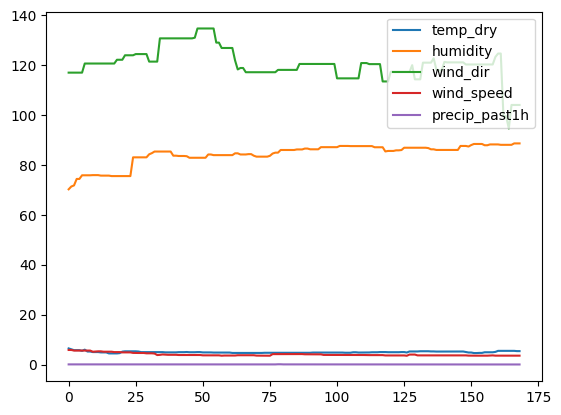

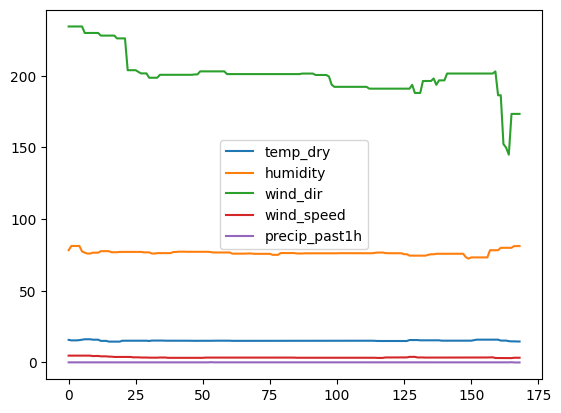

In [16]:
model = MultiOutputRegressor(HistGradientBoostingRegressor(max_depth=5, random_state=SEED))
fit_and_score(model, base_sets)

plot_temps(model, datetime(2026, 3, 25, 13), 6.6, 73.2, 987.5, 95, 9.8, 1.2, FEATURES)
plot_temps(model, datetime(2025, 8, 6, 5), 11.4, 88, 1013.9, 238, 4.3, 0, FEATURES)

## Models

### HistGradientBoostringRegressor

In [60]:
model = MultiOutputRegressor(HistGradientBoostingRegressor(random_state=SEED))
params = {
    "estimator__max_depth": range(5, 15),
    "estimator__learning_rate": [0.05, 0.1, 0.2,],
    "estimator__min_samples_leaf": range(30, 50),
    "estimator__max_iter": [10, 25, 50, 100, 200],
    "estimator__max_features": [0.2, 0.4, 0.6, 0.8, 1.0],
    "estimator__max_leaf_nodes": [None, *range(21, 60, 5)]
}
search = RandomizedSearchCV(model, params, random_state=SEED)

search_sets = cyclic_no_year_base_sets
search.fit(*search_sets[0])

print(search.best_estimator_)
compute_metrics(search.best_estimator_, [("train", *(search_sets[0])), ("validate", *(search_sets[1]))])

MultiOutputRegressor(estimator=HistGradientBoostingRegressor(learning_rate=0.05,
                                                             max_depth=8,
                                                             max_features=0.6,
                                                             max_iter=200,
                                                             max_leaf_nodes=None,
                                                             min_samples_leaf=33,
                                                             random_state=42))
                feature  r2_train  r2_validate  RMSE_train  RMSE_validate
0       future_temp_dry  0.903411     0.817090    2.181413       3.038009
1       future_humidity  0.619172     0.326134    9.081879      11.955063
2       future_wind_dir  0.558951     0.239611   60.944881      79.377968
3     future_wind_speed  0.526736     0.228858    1.397707       1.758652
4  future_precip_past1h  0.410173    -0.050907    0.340760       0.471173
5   

In [17]:
model = MultiOutputRegressor(HistGradientBoostingRegressor(max_depth=10, random_state=SEED))
fit_and_score(model, base_sets)

                feature  r2_train  r2_validate  RMSE_train  RMSE_validate
0       future_temp_dry  0.875710     0.806957    2.474523       3.121030
1       future_humidity  0.579189     0.329233    9.546730      11.927543
2       future_wind_dir  0.500053     0.236058   64.886722      79.563184
3     future_wind_speed  0.466418     0.214046    1.484107       1.775461
4  future_precip_past1h  0.442034    -0.063911    0.331429       0.474079
5                   all  0.572681     0.304477   15.744702      19.372260


In [18]:
model = MultiOutputRegressor(HistGradientBoostingRegressor(max_depth=10, random_state=SEED))
fit_and_score(model, base_sets)

                feature  r2_train  r2_validate  RMSE_train  RMSE_validate
0       future_temp_dry  0.875710     0.806957    2.474523       3.121030
1       future_humidity  0.579189     0.329233    9.546730      11.927543
2       future_wind_dir  0.500053     0.236058   64.886722      79.563184
3     future_wind_speed  0.466418     0.214046    1.484107       1.775461
4  future_precip_past1h  0.442034    -0.063911    0.331429       0.474079
5                   all  0.572681     0.304477   15.744702      19.372260


In [19]:
model = MultiOutputRegressor(HistGradientBoostingRegressor(max_depth=10, random_state=SEED))
fit_and_score(model, no_year_sets)

                feature  r2_train  r2_validate  RMSE_train  RMSE_validate
0       future_temp_dry  0.876596     0.811236    2.465696       3.086243
1       future_humidity  0.572606     0.323899    9.621111      11.974873
2       future_wind_dir  0.502109     0.232232   64.753167      79.762192
3     future_wind_speed  0.460970     0.208998    1.491664       1.781155
4  future_precip_past1h  0.438108    -0.061896    0.332593       0.473630
5                   all  0.570078     0.302894   15.732846      19.415619


In [20]:
model = MultiOutputRegressor(HistGradientBoostingRegressor(max_depth=10, random_state=SEED))
fit_and_score(model, cyclic_base_sets)

                feature  r2_train  r2_validate  RMSE_train  RMSE_validate
0       future_temp_dry  0.881009     0.816361    2.421204       3.044059
1       future_humidity  0.602001     0.345530    9.284358      11.781750
2       future_wind_dir  0.520312     0.257781   63.558463      78.423831
3     future_wind_speed  0.485254     0.232518    1.457676       1.754474
4  future_precip_past1h  0.482299    -0.056651    0.319246       0.472459
5                   all  0.594175     0.319108   15.408189      19.095315


## More points

In [21]:
model = MultiOutputRegressor(HistGradientBoostingRegressor(max_depth=10, random_state=SEED))
fit_and_score(model, more_points_sets)

                feature  r2_train  r2_validate  RMSE_train  RMSE_validate
0       future_temp_dry  0.886236     0.788209    2.367428       3.269076
1       future_humidity  0.606226     0.240146    9.234949      12.694923
2       future_wind_dir  0.566435     0.221851   60.425588      80.299620
3     future_wind_speed  0.521793     0.187474    1.404987       1.805225
4  future_precip_past1h  0.540352    -0.049059    0.300815       0.470759
5                   all  0.624208     0.277724   14.746753      19.707920


## Scaled

In [22]:
model = MultiOutputRegressor(HistGradientBoostingRegressor(max_depth=10, random_state=SEED))
fit_and_score(model, scaled_base_sets)

                feature  r2_train  r2_validate  RMSE_train  RMSE_validate
0       future_temp_dry  0.875710     0.806957    2.474523       3.121030
1       future_humidity  0.579189     0.329233    9.546730      11.927543
2       future_wind_dir  0.500053     0.236058   64.886722      79.563184
3     future_wind_speed  0.466418     0.214046    1.484107       1.775461
4  future_precip_past1h  0.442034    -0.063911    0.331429       0.474079
5                   all  0.572681     0.304477   15.744702      19.372260


## Random forest

In [23]:
model = MultiOutputRegressor(RandomForestRegressor(max_depth=5, random_state=SEED))
fit_and_score(model, base_sets)

                feature  r2_train  r2_validate  RMSE_train  RMSE_validate
0       future_temp_dry  0.762742     0.752686    3.418887       3.532605
1       future_humidity  0.213554     0.189626   13.051053      13.110155
2       future_wind_dir  0.193131     0.163921   82.431959      83.234933
3     future_wind_speed  0.135173     0.096465    1.889423       1.903642
4  future_precip_past1h  0.221389    -0.016882    0.391514       0.463483
5                   all  0.305197     0.237163   20.236567      20.448964


## SVM

In [24]:
model = MultiOutputRegressor(SVR(kernel="rbf"))
fit_and_score(model, scaled_base_sets)

                feature  r2_train  r2_validate  RMSE_train  RMSE_validate
0       future_temp_dry  0.744046     0.728538    3.551037       3.701052
1       future_humidity  0.105077     0.081857   13.922073      13.954692
2       future_wind_dir  0.078453     0.087853   88.095287      86.938950
3     future_wind_speed  0.137485     0.081405    1.886896       1.919441
4  future_precip_past1h  0.012127    -0.003341    0.440998       0.460387
5                   all  0.215437     0.195262   21.579258      21.394904


In [25]:
model = MultiOutputRegressor(SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1))
fit_and_score(model, scaled_base_sets)

                feature  r2_train  r2_validate  RMSE_train  RMSE_validate
0       future_temp_dry  0.832052     0.751174    2.876484       3.543392
1       future_humidity  0.300147     0.124008   12.311595      13.630608
2       future_wind_dir  0.196091     0.134977   82.280619      84.663419
3     future_wind_speed  0.364929     0.039790    1.619107       1.962438
4  future_precip_past1h  0.155923    -0.053571    0.407641       0.471770
5                   all  0.369828     0.199275   19.899089      20.854325


In [26]:
model = MultiOutputRegressor(SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1))
fit_and_score(model, scaled_cyclic_base_sets)

                feature  r2_train  r2_validate  RMSE_train  RMSE_validate
0       future_temp_dry  0.888907     0.741812    2.339474       3.609437
1       future_humidity  0.456024     0.127411   10.854277      13.604105
2       future_wind_dir  0.319223     0.192479   75.717537      81.801068
3     future_wind_speed  0.616982    -0.030628    1.257402       2.033123
4  future_precip_past1h  0.330392    -0.176445    0.363075       0.498522
5                   all  0.522306     0.170926   18.106353      20.309251


In [27]:
model = MultiOutputRegressor(SVR(kernel="poly", degree=2))
fit_and_score(model, scaled_base_sets)

                feature  r2_train  r2_validate  RMSE_train  RMSE_validate
0       future_temp_dry  0.641552     0.638357    4.202299       4.271798
1       future_humidity  0.071089     0.060732   14.183976      14.114315
2       future_wind_dir  0.060186     0.078807   88.964118      87.368995
3     future_wind_speed  0.043637     0.023790    1.986899       1.978720
4  future_precip_past1h -0.003703    -0.006978    0.444518       0.461220
5                   all  0.162552     0.158942   21.956362      21.639010


In [28]:
model = MultiOutputRegressor(SVR(kernel="poly", degree=3))
fit_and_score(model, scaled_base_sets)

                feature  r2_train  r2_validate  RMSE_train  RMSE_validate
0       future_temp_dry  0.661929     0.630511    4.081108       4.317892
1       future_humidity  0.071806     0.029158   14.178501      14.349585
2       future_wind_dir  0.061817     0.071134   88.886920      87.732086
3     future_wind_speed  0.098639    -0.029627    1.928918       2.032136
4  future_precip_past1h -0.001548    -0.006538    0.444040       0.461120
5                   all  0.178529     0.138928   21.903898      21.778564


## Untrained dates

In [29]:
for include_year in [True, False]:
    pipeline = Pipeline([
        ('column_droppers', FunctionTransformer(lambda X: drop_columns(X, ["pressure"]), )),
        ("before_date_dropper", FunctionTransformer(lambda X: drop_before(X, datetime(2025, 1, 1) - timedelta(days=365*2)))),
        ("after_date_dropper", FunctionTransformer(lambda X: drop_after(X, datetime(2025, 1, 1)))),
        ("NaN_dropper", FunctionTransformer(drop_nan)),
        ("time_spliter", FunctionTransformer(lambda X: split_time(X, year=include_year, make_cyclic=True))),
    ])
    old_sets = get_sets(raw_data, pipeline, FEATURES, seed=SEED, n=100000)

    pipeline = Pipeline([
        ('column_droppers', FunctionTransformer(lambda X: drop_columns(X, ["pressure"]), )),
        ("before_date_dropper", FunctionTransformer(lambda X: drop_before(X, datetime(2025, 1, 1)))),
        ("NaN_dropper", FunctionTransformer(drop_nan)),
        ("time_spliter", FunctionTransformer(lambda X: split_time(X, year=include_year, make_cyclic=True))),
    ])
    new_set = get_sets(raw_data, pipeline, FEATURES, seed=SEED, do_split=False)

    print(f"===== OLD {"with" if include_year else "without"} year =====")
    model = MultiOutputRegressor(HistGradientBoostingRegressor(max_depth=10, random_state=SEED))
    fit_and_score(model, old_sets)

    print(f"===== NEW {"with" if include_year else "without"} year =====")
    compute_metrics(model, [("test",  *new_set),])

===== OLD with year =====
                feature  r2_train  r2_validate  RMSE_train  RMSE_validate
0       future_temp_dry  0.818970     0.754616    2.797141       3.258857
1       future_humidity  0.516786     0.325692    9.994784      11.984366
2       future_wind_dir  0.408895     0.192762   77.665172      93.978643
3     future_wind_speed  0.532725     0.377738    1.150237       1.344285
4  future_precip_past1h  0.399821     0.002544    0.437371       0.679757
5                   all  0.535439     0.330670   18.408941      22.249182
===== NEW with year =====
                feature   r2_test  RMSE_test
0       future_temp_dry  0.697021   3.872674
1       future_humidity  0.165446  13.380960
2       future_wind_dir -0.038490  93.620812
3     future_wind_speed -0.317598   2.312900
4  future_precip_past1h -0.115300   0.452081
5                   all  0.078216  22.727886
===== OLD without year =====
                feature  r2_train  r2_validate  RMSE_train  RMSE_validate
0       futu